In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version : {tf.__version__}")
print(f"NumPy Version      : {np.__version__}")

TensorFlow Version : 2.20.0
NumPy Version      : 2.0.2


# Text Corpus Preparation and Cleaning

In [2]:
corpus = """
deep learning is a powerful branch of artificial intelligence
neural networks learn patterns from large amounts of data
recurrent neural networks process sequential data effectively
long short term memory networks solve the vanishing gradient problem
gated recurrent units are efficient alternatives to long short term memory
natural language processing benefits from deep learning models
text generation models learn grammar structure and contextual dependencies
transformers have revolutionised the field of natural language understanding
attention mechanisms allow models to focus on relevant parts of sequences
language models predict the probability of the next word in a sequence
training deep learning models requires significant computational resources
overfitting occurs when a model memorises training data instead of generalising
dropout regularisation helps prevent overfitting in neural networks
embedding layers convert words into dense vector representations
the softmax function outputs a probability distribution over the vocabulary
"""
def clean_corpus(text):

    text = text.lower()

    text = re.sub(r"[^a-z\s\n]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

print("Cleaned Corpus:\n")
print(corpus)

Cleaned Corpus:


deep learning is a powerful branch of artificial intelligence
neural networks learn patterns from large amounts of data
recurrent neural networks process sequential data effectively
long short term memory networks solve the vanishing gradient problem
gated recurrent units are efficient alternatives to long short term memory
natural language processing benefits from deep learning models
text generation models learn grammar structure and contextual dependencies
transformers have revolutionised the field of natural language understanding
attention mechanisms allow models to focus on relevant parts of sequences
language models predict the probability of the next word in a sequence
training deep learning models requires significant computational resources
overfitting occurs when a model memorises training data instead of generalising
dropout regularisation helps prevent overfitting in neural networks
embedding layers convert words into dense vector representations
the soft

# Tokenization and Vocabulary Creation

In [3]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print(f"\nVocabulary Size: {total_words}")
print("\nSample Word Index Mapping:")

for word, idx in list(tokenizer.word_index.items())[:10]:
    print(f"{word:<15} -> {idx}")


Vocabulary Size: 98

Sample Word Index Mapping:
of              -> 1
the             -> 2
models          -> 3
a               -> 4
networks        -> 5
deep            -> 6
learning        -> 7
neural          -> 8
data            -> 9
language        -> 10


# N-Gram Sequence Construction

In [4]:
input_sequences = []

for line in corpus.split("\n"):

    line = line.strip()

    if not line:
        continue

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i + 1]
        input_sequences.append(n_gram_seq)

print(f"\nTotal Training Sequences: {len(input_sequences)}")

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding="pre"
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print(f"Maximum Sequence Length : {max_len}")
print(f"X Shape : {X.shape}")
print(f"y Shape : {y.shape}")



Total Training Sequences: 125
Maximum Sequence Length : 12
X Shape : (125, 11)
y Shape : (125,)


In [5]:
EMBEDDING_DIM = 128
HIDDEN_UNITS = 128
EPOCHS = 200

# Padding and Dataset Creation

In [6]:
def build_and_train(rnn_layer, model_name):

    model = Sequential([
        Embedding(
            input_dim=total_words,
            output_dim=EMBEDDING_DIM
        ),

        rnn_layer,

        Dense(
            total_words,
            activation='softmax'
        )
    ])

    model.build(input_shape=(None, max_len - 1))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"\n{'='*50}")
    print(f"{model_name} MODEL")
    print(f"{'='*50}")

    model.summary()

    history = model.fit(
        X,
        y,
        epochs=EPOCHS,
        verbose=0
    )

    print(
        f"{model_name} Training Complete | "
        f"Final Loss: {history.history['loss'][-1]:.4f} | "
        f"Final Accuracy: {history.history['accuracy'][-1]:.4f}"
    )

    return model, history

# Vanilla RNN

In [7]:
print("\nTraining Vanilla RNN")

rnn_model, rnn_history = build_and_train(
    SimpleRNN(HIDDEN_UNITS),
    "VanillaRNN"
)


Training Vanilla RNN

VanillaRNN MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 11, 128)        │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 98)             │        12,642 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,082 (226.88 KB)

 Trainable params: 58,082 (226.88 KB)

 Non-trainable params: 0 (0.00 B)

VanillaRNN Training Complete | Final Loss: 0.0072 | Final Accuracy: 1.0000


# LSTM

In [8]:
print("\n Training LSTM")

lstm_model, lstm_history = build_and_train(
    LSTM(HIDDEN_UNITS),
    "LSTM"
)





 Training LSTM

LSTM MODEL


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 11, 128)        │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 98)             │        12,642 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,770 (612.38 KB)

 Trainable params: 156,770 (612.38 KB)

 Non-trainable params: 0 (0.00 B)

LSTM Training Complete | Final Loss: 0.0449 | Final Accuracy: 1.0000


# GRU

In [9]:
print("\n── Training GRU")

gru_model, gru_history = build_and_train(
    GRU(HIDDEN_UNITS),
    "GRU"
)


── Training GRU

GRU MODEL


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 11, 128)        │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 98)             │        12,642 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,258 (485.38 KB)

 Trainable params: 124,258 (485.38 KB)

 Non-trainable params: 0 (0.00 B)

GRU Training Complete | Final Loss: 0.0071 | Final Accuracy: 1.0000


# Training Loss Comparison

The training loss curves of RNN, LSTM, and GRU are compared across all epochs.


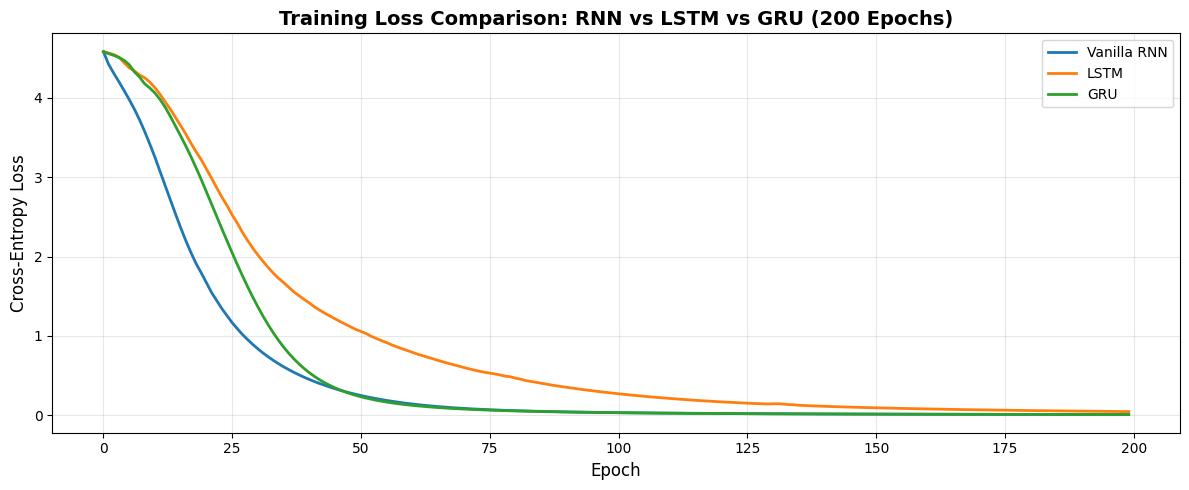

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    rnn_history.history["loss"],
    label="Vanilla RNN",
    linewidth=2
)

plt.plot(
    lstm_history.history["loss"],
    label="LSTM",
    linewidth=2
)

plt.plot(
    gru_history.history["loss"],
    label="GRU",
    linewidth=2
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Cross-Entropy Loss", fontsize=12)

plt.title(
    "Training Loss Comparison: RNN vs LSTM vs GRU (200 Epochs)",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# Text Generation using Next-Word Prediction

In [11]:
index_to_word = {
    idx: word
    for word, idx in tokenizer.word_index.items()
}

def generate_text(model, seed_text, next_words=10):

    generated = seed_text.lower()

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [generated]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len - 1,
            padding="pre"
        )

        prob_array = model.predict(
            token_list,
            verbose=0
        )

        predicted_idx = int(
            np.argmax(prob_array, axis=-1)[0]
        )

        output_word = index_to_word.get(
            predicted_idx,
            "<UNK>"
        )

        generated += " " + output_word

    return generated

# Generated Text Results

In [12]:
SEED = "deep learning"
N_WORDS = 10

print("\nGenerated Text Comparison")
print("=" * 50)

print(
    "\nRNN:\n",
    generate_text(
        rnn_model,
        SEED,
        N_WORDS
    )
)

print(
    "\nLSTM:\n",
    generate_text(
        lstm_model,
        SEED,
        N_WORDS
    )
)

print(
    "\nGRU:\n",
    generate_text(
        gru_model,
        SEED,
        N_WORDS
    )
)


Generated Text Comparison

RNN:
 deep learning is a powerful branch of artificial intelligence of significant computational

LSTM:
 deep learning is a powerful branch of artificial intelligence intelligence sequences sequence

GRU:
 deep learning is a powerful branch of artificial intelligence intelligence intelligence sequences


# Model Performance Summary

In [13]:
print("\nMODEL COMPARISON SUMMARY")
print("=" * 65)

print(f"{'Model':<10}{'Loss':<12}{'Accuracy':<12}{'Parameters':<15}")

for name, history, model in [
    ("RNN", rnn_history, rnn_model),
    ("LSTM", lstm_history, lstm_model),
    ("GRU", gru_history, gru_model)
]:

    loss = history.history["loss"][-1]
    acc = history.history["accuracy"][-1]
    params = model.count_params()

    print(
        f"{name:<10}"
        f"{loss:<12.4f}"
        f"{acc:<12.4f}"
        f"{params:<15,}"
    )




MODEL COMPARISON SUMMARY
Model     Loss        Accuracy    Parameters     
RNN       0.0072      1.0000      58,082         
LSTM      0.0449      1.0000      156,770        
GRU       0.0071      1.0000      124,258        


#Conclusion

### Key Findings

- Vanilla RNN successfully learns short-term sequential patterns.
- LSTM effectively captures long-term dependencies using memory gates.
- GRU achieves comparable performance with fewer parameters than LSTM.
- All models learned the corpus structure and generated meaningful text.
- Due to the small dataset and extended training, all models achieved very high training accuracy.

### Overall Observation

For real-world text generation tasks involving longer contexts, LSTM and GRU are generally preferred because they better preserve contextual information and mitigate the vanishing gradient problem.